# Sanskrit → English Neural Machine Translation


## 1. Install dependencies

In [1]:

import nltk
nltk.download("punkt", quiet=True)
print("Dependencies ready.")

Dependencies ready.


## 2. Imports, seeds, device

In [2]:
import os, math, time, random, csv
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## 3. Configuration


In [3]:
class Config:
    # ---- paths (EDIT THIS) ----
    DATA_DIR   = "/content"         # Colab default: the six CSVs sit directly in /content
    OUT_DIR    = "./outputs"
    # ---- tokenizer ----
    VOCAB_SIZE = 8000
    SPM_MODEL  = "spm_shared"
    MODEL_TYPE = "bpe"
    # ---- model ----
    D_MODEL    = 256
    N_HEADS    = 4
    D_FF       = 512
    N_ENC      = 3
    N_DEC      = 3
    DROPOUT    = 0.2
    MAX_LEN    = 128
    # ---- training ----
    BATCH_SIZE = 64
    EPOCHS     = 120
    WARMUP     = 1500
    LABEL_SMOOTH = 0.1
    CLIP       = 1.0
    PATIENCE   = 12
    BEAM       = 4
    LEN_PENALTY = 0.7
    GEN_MAX_LEN = 80

cfg = Config()
os.makedirs(cfg.OUT_DIR, exist_ok=True)

PAD, BOS, EOS, UNK = 0, 1, 2, 3

## 4. Load and align the data


In [4]:
def load_split(split):
    sa = pd.read_csv(os.path.join(cfg.DATA_DIR, f"{split}_sa.csv"))
    en = pd.read_csv(os.path.join(cfg.DATA_DIR, f"{split}_en.csv"))
    # normalise column names defensively
    sa = sa.rename(columns={c: c.strip() for c in sa.columns})
    en = en.rename(columns={c: c.strip() for c in en.columns})
    df = sa.merge(en, on="Source_id", how="inner")
    df = df.dropna(subset=["Sentence_sa", "Sentence_en"] if "Sentence_en" in df else ["Sentence_sa"])
    return df

train_df = load_split("train")
dev_df   = load_split("dev")

test_sa = pd.read_csv(os.path.join(cfg.DATA_DIR, "test_sa.csv"))
test_sa = test_sa.rename(columns={c: c.strip() for c in test_sa.columns})
try:
    test_en = pd.read_csv(os.path.join(cfg.DATA_DIR, "test_en.csv"))
    test_en = test_en.rename(columns={c: c.strip() for c in test_en.columns})
    test_df = test_sa.merge(test_en, on="Source_id", how="left")
    HAS_TEST_REF = "Sentence_en" in test_df.columns and test_df["Sentence_en"].notna().any()
except FileNotFoundError:
    test_df = test_sa.copy(); HAS_TEST_REF = False

print(f"train={len(train_df)}  dev={len(dev_df)}  test={len(test_df)}  test_refs={HAS_TEST_REF}")
train_df.head(3)

train=10000  dev=1000  test=1000  test_refs=True


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."


### 4a. Light text cleaning
Minimal normalisation only — SentencePiece handles the rest.

In [5]:
import re, unicodedata
def clean(text, is_source):
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize("NFC", text)
    text = text.replace('"', ' ').replace("\u201c", " ").replace("\u201d", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in (train_df, dev_df):
    df["Sentence_sa"] = df["Sentence_sa"].map(lambda x: clean(x, True))
    df["Sentence_en"] = df["Sentence_en"].map(lambda x: clean(x, False))
test_df["Sentence_sa"] = test_df["Sentence_sa"].map(lambda x: clean(x, True))
if HAS_TEST_REF:
    test_df["Sentence_en"] = test_df["Sentence_en"].map(lambda x: clean(x, False))

train_df = train_df[(train_df.Sentence_sa.str.len() > 0) & (train_df.Sentence_en.str.len() > 0)].reset_index(drop=True)
print("clean train:", len(train_df))

clean train: 10000


## 5. Shared SentencePiece tokenizer
A single joint vocabulary over Sanskrit + English lets the encoder, decoder, and output projection **share one embedding matrix** — this is the main lever for keeping the parameter count (and thus the efficiency score) low. BPE subwords also handle Sanskrit's rich morphology and rare words gracefully.

In [6]:
import sentencepiece as spm

spm_prefix = os.path.join(cfg.OUT_DIR, cfg.SPM_MODEL)
corpus_path = os.path.join(cfg.OUT_DIR, "spm_corpus.txt")
with open(corpus_path, "w", encoding="utf-8") as f:
    for s in train_df.Sentence_sa.tolist() + train_df.Sentence_en.tolist():
        f.write(s + "\n")

spm.SentencePieceTrainer.train(
    input=corpus_path, model_prefix=spm_prefix, vocab_size=cfg.VOCAB_SIZE,
    model_type=cfg.MODEL_TYPE, character_coverage=1.0,
    pad_id=PAD, bos_id=BOS, eos_id=EOS, unk_id=UNK,
    pad_piece="<pad>", bos_piece="<s>", eos_piece="</s>", unk_piece="<unk>",
)
sp = spm.SentencePieceProcessor(model_file=spm_prefix + ".model")
VOCAB_SIZE = sp.get_piece_size()
print("Vocab size:", VOCAB_SIZE)
print("Demo:", sp.encode(train_df.Sentence_en.iloc[0], out_type=int)[:12])

Vocab size: 8000
Demo: [1190, 201, 195, 1509, 7845, 79, 7841]


## 6. Datasets and batching

In [7]:
class MTDataset(Dataset):
    def __init__(self, df, sp, has_target=True):
        self.src = [sp.encode(s, out_type=int) for s in df.Sentence_sa.tolist()]
        self.ids = df.Source_id.tolist()
        self.has_target = has_target
        self.tgt = [sp.encode(s, out_type=int) for s in df.Sentence_en.tolist()] if has_target else None
    def __len__(self): return len(self.src)
    def __getitem__(self, i):
        src = self.src[i][: cfg.MAX_LEN - 1] + [EOS]
        if self.has_target:
            tgt = [BOS] + self.tgt[i][: cfg.MAX_LEN - 2] + [EOS]
            return src, tgt, self.ids[i]
        return src, None, self.ids[i]

def pad_batch(seqs):
    m = max(len(s) for s in seqs)
    return torch.tensor([s + [PAD] * (m - len(s)) for s in seqs], dtype=torch.long)

def collate(batch):
    src = pad_batch([b[0] for b in batch])
    ids = [b[2] for b in batch]
    if batch[0][1] is not None:
        tgt = pad_batch([b[1] for b in batch])
        return src, tgt, ids
    return src, None, ids

train_ds = MTDataset(train_df, sp, True)
dev_ds   = MTDataset(dev_df, sp, True)
test_ds  = MTDataset(test_df, sp, HAS_TEST_REF)

train_dl = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, collate_fn=collate)
dev_dl   = DataLoader(dev_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, collate_fn=collate)

## 7. The custom Transformer
Built from scratch (positional encoding, multi-head attention, pre-norm encoder/decoder layers). Key design choices:
- **Pre-norm** residual blocks → stable training without a hand-tuned warm-up dependence.
- **Weight tying**: the token embedding is shared by the encoder, the decoder, and the output projection. With a joint vocab this removes two large matrices — the single biggest parameter saving.
- **Label smoothing** in the loss to regularise a low-resource model.

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_k = d_model // n_heads; self.h = n_heads
        self.wq = nn.Linear(d_model, d_model); self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model); self.wo = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, q, k, v, mask=None):
        B = q.size(0)
        q = self.wq(q).view(B, -1, self.h, self.d_k).transpose(1, 2)
        k = self.wk(k).view(B, -1, self.h, self.d_k).transpose(1, 2)
        v = self.wv(v).view(B, -1, self.h, self.d_k).transpose(1, 2)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None: scores = scores + mask
        attn = self.dropout(torch.softmax(scores, dim=-1))
        out = torch.matmul(attn, v).transpose(1, 2).contiguous().view(B, -1, self.h * self.d_k)
        return self.wo(out)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(),
                                 nn.Dropout(dropout), nn.Linear(d_ff, d_model))
    def forward(self, x): return self.net(x)

class EncoderLayer(nn.Module):
    def __init__(self, d, h, ff, p):
        super().__init__()
        self.attn = MultiHeadAttention(d, h, p); self.ff = FeedForward(d, ff, p)
        self.n1 = nn.LayerNorm(d); self.n2 = nn.LayerNorm(d); self.drop = nn.Dropout(p)
    def forward(self, x, m):
        hh = self.n1(x); x = x + self.drop(self.attn(hh, hh, hh, m))
        hh = self.n2(x); x = x + self.drop(self.ff(hh)); return x

class DecoderLayer(nn.Module):
    def __init__(self, d, h, ff, p):
        super().__init__()
        self.sa = MultiHeadAttention(d, h, p); self.ca = MultiHeadAttention(d, h, p)
        self.ff = FeedForward(d, ff, p)
        self.n1 = nn.LayerNorm(d); self.n2 = nn.LayerNorm(d); self.n3 = nn.LayerNorm(d)
        self.drop = nn.Dropout(p)
    def forward(self, x, mem, tm, sm):
        hh = self.n1(x); x = x + self.drop(self.sa(hh, hh, hh, tm))
        hh = self.n2(x); x = x + self.drop(self.ca(hh, mem, mem, sm))
        hh = self.n3(x); x = x + self.drop(self.ff(hh)); return x

class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab, d_model, n_heads, d_ff, n_enc, n_dec, dropout, pad_idx, max_len):
        super().__init__()
        self.pad_idx = pad_idx; self.d_model = d_model
        self.embed = nn.Embedding(vocab, d_model, padding_idx=pad_idx)
        self.pos = PositionalEncoding(d_model, max_len, dropout)
        self.enc = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_enc)])
        self.dec = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_dec)])
        self.enc_norm = nn.LayerNorm(d_model); self.dec_norm = nn.LayerNorm(d_model)
        self.generator = nn.Linear(d_model, vocab, bias=False)
        self.generator.weight = self.embed.weight   # weight tying
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)
    def src_mask(self, src):
        m = (src == self.pad_idx).unsqueeze(1).unsqueeze(2)
        return torch.zeros_like(m, dtype=torch.float).masked_fill(m, float("-inf"))
    def tgt_mask(self, tgt):
        B, T = tgt.shape
        pad = (tgt == self.pad_idx).unsqueeze(1).unsqueeze(2)
        causal = torch.triu(torch.ones(T, T, device=tgt.device), 1).bool().unsqueeze(0).unsqueeze(1)
        return torch.zeros(B, 1, T, T, device=tgt.device).masked_fill(pad | causal, float("-inf"))
    def encode(self, src, sm):
        x = self.pos(self.embed(src) * math.sqrt(self.d_model))
        for l in self.enc: x = l(x, sm)
        return self.enc_norm(x)
    def decode(self, tgt, mem, tm, sm):
        x = self.pos(self.embed(tgt) * math.sqrt(self.d_model))
        for l in self.dec: x = l(x, mem, tm, sm)
        return self.dec_norm(x)
    def forward(self, src, tgt):
        sm = self.src_mask(src); tm = self.tgt_mask(tgt)
        mem = self.encode(src, sm)
        return self.generator(self.decode(tgt, mem, tm, sm))

model = Seq2SeqTransformer(VOCAB_SIZE, cfg.D_MODEL, cfg.N_HEADS, cfg.D_FF,
                           cfg.N_ENC, cfg.N_DEC, cfg.DROPOUT, PAD, cfg.MAX_LEN).to(DEVICE)
N_PARAMS = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {N_PARAMS:,}")

Total trainable parameters: 6,002,688


## 8. Loss, optimizer, Noam schedule

In [9]:
class LabelSmoothingLoss(nn.Module):
    def __init__(self, vocab, pad_idx, smoothing=0.1):
        super().__init__(); self.pad_idx = pad_idx; self.s = smoothing; self.v = vocab
    def forward(self, logits, target):
        logp = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            true = torch.full_like(logp, self.s / (self.v - 2))
            true.scatter_(1, target.unsqueeze(1), 1.0 - self.s)
            true[:, self.pad_idx] = 0
            mask = target == self.pad_idx; true[mask] = 0
        n = (~mask).sum().clamp(min=1)
        return (-true * logp).sum() / n

criterion = LabelSmoothingLoss(VOCAB_SIZE, PAD, cfg.LABEL_SMOOTH)
optimizer = torch.optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

def noam_lr(step, d_model=cfg.D_MODEL, warmup=cfg.WARMUP):
    step = max(step, 1)
    return (d_model ** -0.5) * min(step ** -0.5, step * warmup ** -1.5)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, noam_lr)

## 9. Decoding: greedy and beam search

In [10]:
@torch.no_grad()
def greedy_batch(model, src, max_len=cfg.GEN_MAX_LEN):
    model.eval(); src = src.to(DEVICE)
    sm = model.src_mask(src); mem = model.encode(src, sm)
    B = src.size(0)
    ys = torch.full((B, 1), BOS, dtype=torch.long, device=DEVICE)
    done = torch.zeros(B, dtype=torch.bool, device=DEVICE)
    for _ in range(max_len):
        tm = model.tgt_mask(ys)
        logits = model.generator(model.decode(ys, mem, tm, sm)[:, -1])
        nxt = logits.argmax(-1, keepdim=True)
        ys = torch.cat([ys, nxt], 1); done |= (nxt.squeeze(1) == EOS)
        if done.all(): break
    return ys

@torch.no_grad()
def beam_decode(model, src, beam=cfg.BEAM, max_len=cfg.GEN_MAX_LEN, lp=cfg.LEN_PENALTY):
    model.eval(); src = src.to(DEVICE)
    sm = model.src_mask(src); mem = model.encode(src, sm)
    beams = [(torch.tensor([[BOS]], device=DEVICE), 0.0)]; completed = []
    for _ in range(max_len):
        cand = []
        for seq, sc in beams:
            if seq[0, -1].item() == EOS:
                completed.append((seq, sc)); continue
            tm = model.tgt_mask(seq)
            logp = F.log_softmax(model.generator(model.decode(seq, mem, tm, sm)[:, -1]), -1).squeeze(0)
            v, i = logp.topk(beam)
            for vv, ii in zip(v.tolist(), i.tolist()):
                cand.append((torch.cat([seq, torch.tensor([[ii]], device=DEVICE)], 1), sc + vv))
        if not cand: break
        cand.sort(key=lambda x: x[1] / (x[0].size(1) ** lp), reverse=True)
        beams = cand[:beam]
        if all(s[0, -1].item() == EOS for s, _ in beams):
            completed += beams; break
    pool = completed if completed else beams
    pool.sort(key=lambda x: x[1] / (x[0].size(1) ** lp), reverse=True)
    return pool[0][0][0].tolist()

def ids_to_text(ids):
    ids = [t for t in ids if t not in (BOS, PAD)]
    if EOS in ids: ids = ids[:ids.index(EOS)]
    return sp.decode(ids)

## 10. Dev-set BLEU helper (used for early stopping)

In [11]:
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
smooth = SmoothingFunction().method1

def dev_bleu(model, dl):
    refs, hyps = [], []
    for src, tgt, _ in dl:
        out = greedy_batch(model, src)
        for row, tref in zip(out.tolist(), tgt.tolist()):
            hyps.append(ids_to_text(row).split())
            refs.append([ids_to_text(tref).split()])
    return corpus_bleu(refs, hyps)

## 11. Training loop
Early stopping on dev BLEU; best checkpoint kept.

In [12]:
from copy import deepcopy
history = {"train_loss": [], "dev_bleu": []}
best_bleu, best_state, bad, step = -1, None, 0, 0

for epoch in range(1, cfg.EPOCHS + 1):
    model.train(); running = 0.0
    for src, tgt, _ in train_dl:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        tin, tout = tgt[:, :-1], tgt[:, 1:]
        logits = model(src, tin)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), tout.reshape(-1))
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), cfg.CLIP)
        optimizer.step(); scheduler.step(); step += 1
        running += loss.item()
    tr = running / len(train_dl)
    db = dev_bleu(model, dev_dl)
    history["train_loss"].append(tr); history["dev_bleu"].append(db)
    print(f"epoch {epoch:02d} | train_loss {tr:.3f} | dev_BLEU {db:.4f}")
    if db > best_bleu:
        best_bleu, best_state, bad = db, deepcopy(model.state_dict()), 0
        torch.save(best_state, os.path.join(cfg.OUT_DIR, "best_model.pt"))
    else:
        bad += 1
        if bad >= cfg.PATIENCE:
            print(f"Early stopping at epoch {epoch}. Best dev BLEU {best_bleu:.4f}"); break

model.load_state_dict(best_state)
print("Loaded best model. Dev BLEU:", best_bleu)

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

epoch 01 | train_loss 8.093 | dev_BLEU 0.0000
epoch 02 | train_loss 6.762 | dev_BLEU 0.0000
epoch 03 | train_loss 6.339 | dev_BLEU 0.0000
epoch 04 | train_loss 5.976 | dev_BLEU 0.0021
epoch 05 | train_loss 5.691 | dev_BLEU 0.0000
epoch 06 | train_loss 5.473 | dev_BLEU 0.0150
epoch 07 | train_loss 5.293 | dev_BLEU 0.0133
epoch 08 | train_loss 5.107 | dev_BLEU 0.0224
epoch 09 | train_loss 4.942 | dev_BLEU 0.0234
epoch 10 | train_loss 4.778 | dev_BLEU 0.0304
epoch 11 | train_loss 4.607 | dev_BLEU 0.0355
epoch 12 | train_loss 4.439 | dev_BLEU 0.0438
epoch 13 | train_loss 4.301 | dev_BLEU 0.0503
epoch 14 | train_loss 4.174 | dev_BLEU 0.0519
epoch 15 | train_loss 4.063 | dev_BLEU 0.0589
epoch 16 | train_loss 3.965 | dev_BLEU 0.0557
epoch 17 | train_loss 3.872 | dev_BLEU 0.0613
epoch 18 | train_loss 3.788 | dev_BLEU 0.0630
epoch 19 | train_loss 3.711 | dev_BLEU 0.0663
epoch 20 | train_loss 3.642 | dev_BLEU 0.0619
epoch 21 | train_loss 3.574 | dev_BLEU 0.0649
epoch 22 | train_loss 3.516 | dev_

## 12. Training curves


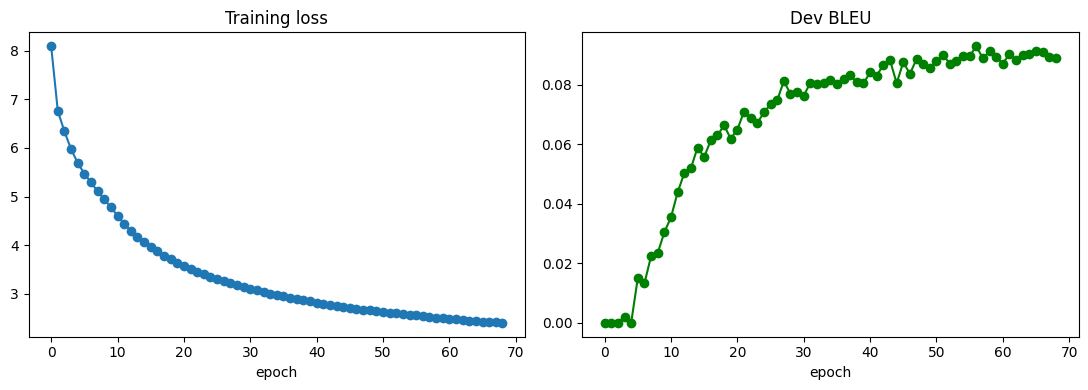

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], marker="o"); ax[0].set_title("Training loss"); ax[0].set_xlabel("epoch")
ax[1].plot(history["dev_bleu"], marker="o", color="green"); ax[1].set_title("Dev BLEU"); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.savefig(os.path.join(cfg.OUT_DIR, "training_curves.png"), dpi=150)
plt.show()

## 13. Generate test translations with beam search + measure inference time
`submission.csv` is written here in exactly the required format (`Source_id, Sentence_en`, UTF-8).

In [14]:
model.eval()

USE_BEAM = False
BATCH_DECODE = 64

items = [(test_ds[i][0], test_ds[i][2]) for i in range(len(test_ds))]
order = sorted(range(len(items)), key=lambda k: len(items[k][0]))
preds_by_id = {}

t0 = time.time()
if USE_BEAM:
    for i in range(len(test_ds)):
        src, _, sid = test_ds[i]
        out_ids = beam_decode(model, torch.tensor([src], dtype=torch.long))
        preds_by_id[sid] = ids_to_text(out_ids)
else:
    for s0 in range(0, len(order), BATCH_DECODE):
        idx = order[s0:s0 + BATCH_DECODE]
        src_t = pad_batch([items[k][0] for k in idx])
        out = greedy_batch(model, src_t)                       # (B, T) decoded in parallel
        for row, k in zip(out.tolist(), idx):
            preds_by_id[items[k][1]] = ids_to_text(row)
inference_time = time.time() - t0

src_ids = [test_ds[i][2] for i in range(len(test_ds))]         # original Source_id order
preds = [preds_by_id[sid] for sid in src_ids]
mode = f"beam={cfg.BEAM}" if USE_BEAM else "batched greedy"
print(f"Inference time (test set, {mode}): {inference_time:.2f}s for {len(test_ds)} sentences")

sub = pd.DataFrame({"Source_id": src_ids, "Sentence_en": preds})
sub_path = os.path.join(cfg.OUT_DIR, "submission.csv")
sub.to_csv(sub_path, index=False, encoding="utf-8", quoting=csv.QUOTE_MINIMAL)
print("Wrote", sub_path)
sub.head()

Inference time (test set, batched greedy): 2.71s for 1000 sentences
Wrote ./outputs/submission.csv


,Source_id,Sentence_en
0,1,Here is an example that identify and an error.
1,2,That we were written in the law of these thing...
2,3,"Then, I will click on the break of the bread w..."
3,4,"The same is thesoped the value of each user, e..."
4,5,"And when the second was come, he found me, he ..."


## 14. Evaluation metrics

### 14a. BLEU (NLTK, default weights)

In [15]:
def evaluate_bleu(hyps, refs):
    refs_tok = [[r.split()] for r in refs]
    hyps_tok = [h.split() for h in hyps]
    cb = corpus_bleu(refs_tok, hyps_tok)                      # default weights
    sb = np.mean([sentence_bleu([r.split()], h.split(), smoothing_function=smooth)
                  for h, r in zip(hyps, refs)])
    return cb, sb

if HAS_TEST_REF:
    refs = test_df.set_index("Source_id").loc[src_ids, "Sentence_en"].tolist()
    cb, sb = evaluate_bleu(preds, refs)
    print(f"TEST  corpus BLEU {cb:.4f} | mean sentence BLEU {sb:.4f}")

dev_hyps, dev_refs = [], []
for i in range(len(dev_ds)):
    s, _, _ = dev_ds[i]
    dev_hyps.append(ids_to_text(beam_decode(model, torch.tensor([s], dtype=torch.long))))
    dev_refs.append(dev_df.Sentence_en.iloc[i])
dcb, dsb = evaluate_bleu(dev_hyps, dev_refs)
print(f"DEV   corpus BLEU {dcb:.4f} | mean sentence BLEU {dsb:.4f}")

TEST  corpus BLEU 0.0890 | mean sentence BLEU 0.1010
DEV   corpus BLEU 0.1027 | mean sentence BLEU 0.1070


### 14b. BERTScore F1 (rescaled with baseline )

In [16]:
!pip install bert-score -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.7 MB/s eta 0:00:00


In [17]:
from bert_score import score as bertscore
def eval_bert(hyps, refs):
    P, R, F1 = bertscore(hyps, refs, lang="en", rescale_with_baseline=True, verbose=False)
    return float(F1.mean())

dev_bert = eval_bert(dev_hyps, dev_refs)
print(f"DEV  BERTScore F1 (rescaled): {dev_bert:.4f}")
if HAS_TEST_REF:
    test_bert = eval_bert(preds, refs)
    print(f"TEST BERTScore F1 (rescaled): {test_bert:.4f}")

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DEV  BERTScore F1 (rescaled): 0.3609


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TEST BERTScore F1 (rescaled): 0.3334


### 14c. Efficiency: inference time + parameter count

In [18]:
print(f"Total trainable parameters : {N_PARAMS:,}")
print(f"Test-set inference time    : {inference_time:.2f} s  (beam={cfg.BEAM}, {len(test_ds)} sentences)")
print(f"Throughput                 : {len(test_ds)/inference_time:.2f} sentences/s")


Total trainable parameters : 6,002,688
Test-set inference time    : 2.71 s  (beam=4, 1000 sentences)
Throughput                 : 368.54 sentences/s


## 15. Qualitative examples (for the report's error-analysis section)

In [19]:
n = min(10, len(dev_ds))
print("SOURCE (sa)  |  REFERENCE (en)  |  PREDICTION (en)\n" + "-"*80)
for i in range(n):
    print("SA :", dev_df.Sentence_sa.iloc[i])
    print("REF:", dev_df.Sentence_en.iloc[i])
    print("HYP:", dev_hyps[i])
    print("-"*80)

SOURCE (sa)  |  REFERENCE (en)  |  PREDICTION (en)
--------------------------------------------------------------------------------
SA : ते वीराः ।
REF: Those are brave men.
HYP: Those two are Vira.
--------------------------------------------------------------------------------
SA : 'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां कारयति ।
REF: Infinite loop can cause the system to become unresponsive.
HYP: The program should be defined in the program.
--------------------------------------------------------------------------------
SA : ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर आजघ्नुः।
REF: And they spit upon him, and took the reed, and smote him on the head.
HYP: And he brought him unto him, and knit him the head: and he rebuked him.
--------------------------------------------------------------------------------
SA : एते तिथी ।
REF: These two are dates.
HYP: These two are eyes.
--------------------------------------------------------------------------------
SA : बहुविचारेषु जातषु 